<a href="https://colab.research.google.com/github/Supriya6462/AI-and-Machine-Learning/blob/main/Worksheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI\ML/DATA/Copy of devnagari digit.zip'
data_path = '/content/drive/MyDrive/AI ML 2026/data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_7331/1750583652.py:4: SyntaxWarning: invalid escape sequence '\M'
  zip_file_path = '/content/drive/MyDrive/AI\ML/DATA/Copy of devnagari digit.zip'


Successfully unzipped '/content/drive/MyDrive/AI\ML/DATA/Copy of devnagari digit.zip' to '/content/drive/MyDrive/AI ML 2026'


In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# Paths (adjust if needed)
train_dir = "/content/drive/MyDrive/AI ML 2026/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML 2026/DevanagariHandwrittenDigitDataset/Test"

img_size = 28

def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")  # grayscale
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0  # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(17000, 28, 28, 1) (17000, 10)
(3000, 28, 28, 1) (3000, 10)


#Task 2: Build FCN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28, 1)),

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

#Task 3: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Task 4: Train Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=3)
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3098 - loss: 1.9266

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5078 - loss: 1.5601 - val_accuracy: 0.0000e+00 - val_loss: 7.5786
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8204 - loss: 0.5123 - val_accuracy: 0.0000e+00 - val_loss: 8.8542
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8957 - loss: 0.3021 - val_accuracy: 0.0000e+00 - val_loss: 9.5007
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9411 - loss: 0.2031 - val_accuracy: 0.0000e+00 - val_loss: 9.8472


#(Extra) Visualization (IMPORTANT for marks)

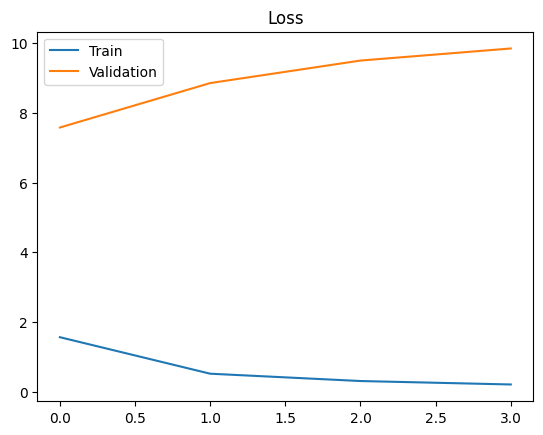

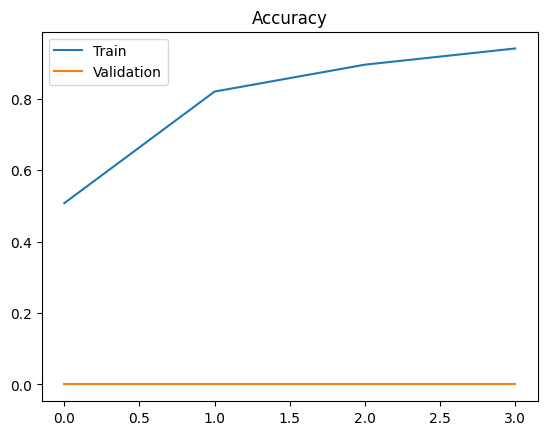

In [ ]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

#Task 5: Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7583 - loss: 2.1247
Test Accuracy: 0.7583333253860474


#Task 6: Save & Load Model

In [ ]:
# Save
model.save("devnagari_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("devnagari_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7583 - loss: 2.1247
Loaded Model Accuracy: 0.7583333253860474


#Task 7: Predictions

In [ ]:
predictions = model.predict(x_test)

# Convert probabilities → labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Example output
for i in range(5):
    print(f"Predicted: {predicted_labels[i]}, True: {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
